In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("data/MA_SVI_Data.csv")

# Quick first look
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (1613, 158)

Column names:
['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AGE17', 'EP_DISABL', 'MP_DISABL', 'EP_SNGPNT', 'MP_SNGPNT', 'EP_LIMENG', 'MP_LIMENG', 'EP_MINRTY', 'MP_MINRTY', 'EP_MUNIT', 'MP_MUNIT', 'EP_MOBILE', 'MP_MOBILE', 'EP_CROWD', 'MP_CROWD', 'EP_NOVEH', 'MP_NOVEH', 'EP_GROUPQ', 'MP_GROUPQ', 'EPL_POV150', 'EPL_UNEMP', 'EPL_HBURD', 'EPL_NOHSDP', 

In [3]:
# Replace SVI's missing value sentinel with NaN
df = df.replace(-999, pd.NA)

# Drop tracts with no overall SVI score
df_clean = df.dropna(subset=['RPL_THEMES']).copy()

# Keep only the columns we need
cols_of_interest = [
    'FIPS', 'COUNTY', 'LOCATION',
    'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4',
    'E_TOTPOP', 'E_POV150', 'E_UNEMP', 'E_UNINSUR', 'E_MINRTY',
    'EP_POV150', 'EP_UNEMP', 'EP_UNINSUR', 'EP_MINRTY',
    'EP_AFAM', 'EP_HISP', 'EP_ASIAN', 'EP_NOINT'
]

df_subset = df_clean[cols_of_interest].copy()

print(f"Tracts after cleaning: {df_subset.shape[0]}")
print(f"\nMissing values per column:")
print(df_subset.isnull().sum())

# Save for Power BI
df_subset.to_csv("output/MA_SVI_clean.csv", index=False)
df_subset.to_excel("output/MA_SVI_clean.xlsx", index=False)

Tracts after cleaning: 1594

Missing values per column:
FIPS          0
COUNTY        0
LOCATION      0
RPL_THEMES    0
RPL_THEME1    0
RPL_THEME2    0
RPL_THEME3    0
RPL_THEME4    0
E_TOTPOP      0
E_POV150      0
E_UNEMP       0
E_UNINSUR     0
E_MINRTY      0
EP_POV150     0
EP_UNEMP      0
EP_UNINSUR    0
EP_MINRTY     0
EP_AFAM       0
EP_HISP       0
EP_ASIAN      0
EP_NOINT      0
dtype: int64


In [5]:
county_summary = df_subset.groupby('COUNTY').apply(
    lambda g: pd.Series({
        'avg_overall_svi':       (g['RPL_THEMES'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'avg_socioeconomic':     (g['RPL_THEME1'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'avg_household':         (g['RPL_THEME2'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'avg_minority':          (g['RPL_THEME3'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'avg_housing_transport': (g['RPL_THEME4'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'pct_uninsured':         (g['EP_UNINSUR'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'pct_poverty':           (g['EP_POV150'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'pct_minority':          (g['EP_MINRTY'] * g['E_TOTPOP']).sum() / g['E_TOTPOP'].sum(),
        'total_pop':              g['E_TOTPOP'].sum(),
        'tract_count':            len(g)
    }), include_groups=False
).reset_index()

county_summary = county_summary.sort_values('avg_overall_svi', ascending=False).reset_index(drop=True)
county_summary.to_csv("output/county_summary.csv", index=False)

print(f"Counties: {len(county_summary)}")
print(county_summary[['COUNTY', 'avg_overall_svi', 'pct_uninsured', 'pct_poverty']].to_string())

Counties: 14
               COUNTY  avg_overall_svi  pct_uninsured  pct_poverty
0      Suffolk County         0.675089       3.490119    25.031714
1      Hampden County         0.639925       3.097414    23.983890
2     Franklin County         0.587100       2.177574    19.886592
3      Bristol County         0.546789       2.915601    17.951022
4        Dukes County         0.535807       6.458210    12.761111
5        Essex County         0.513078       2.937904    16.096751
6    Worcester County         0.504943       2.495450    15.925596
7    Berkshire County         0.504745       2.141960    18.400434
8    Middlesex County         0.421352       2.516276    11.920110
9      Norfolk County         0.420505       1.929707    10.384064
10   Hampshire County         0.393802       2.009322    15.463494
11    Plymouth County         0.387907       2.401567    11.399288
12   Nantucket County         0.363036       4.698329    10.601827
13  Barnstable County         0.360503       3.03

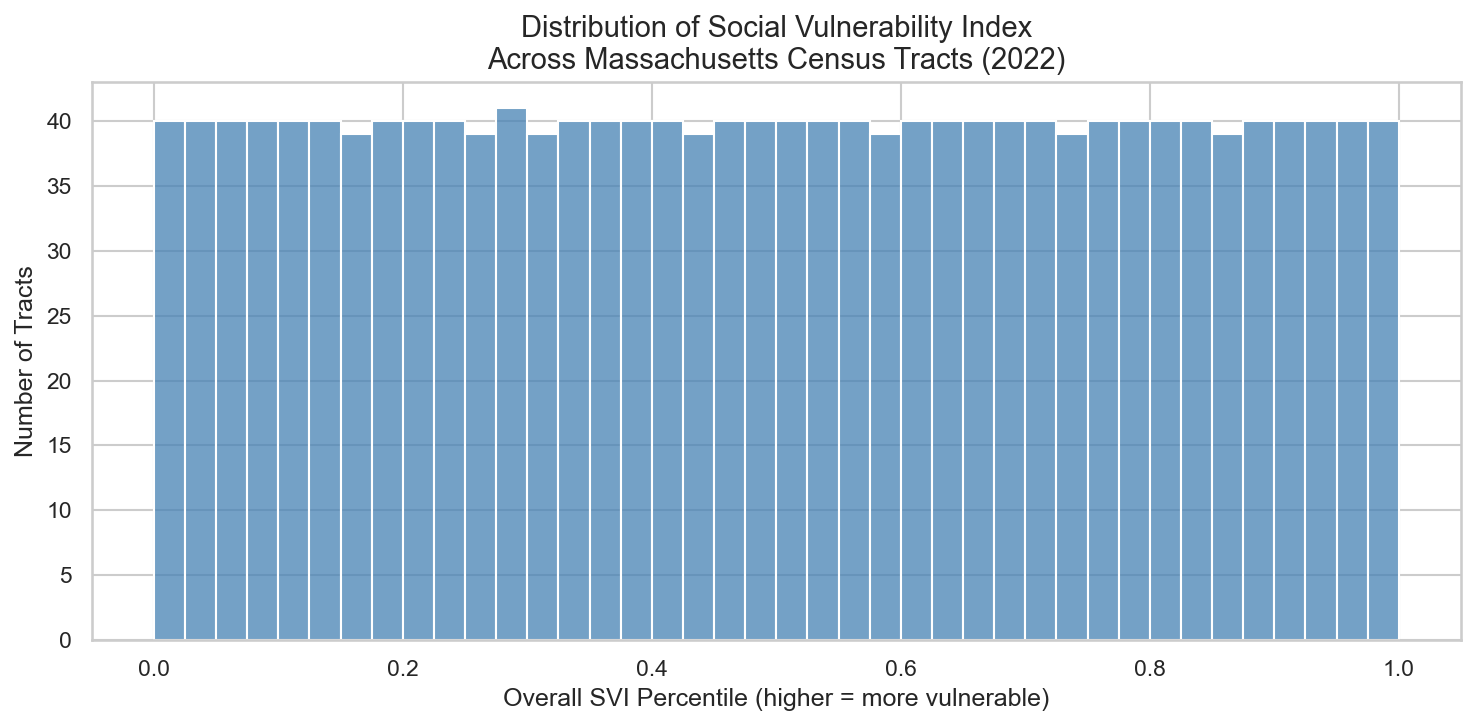

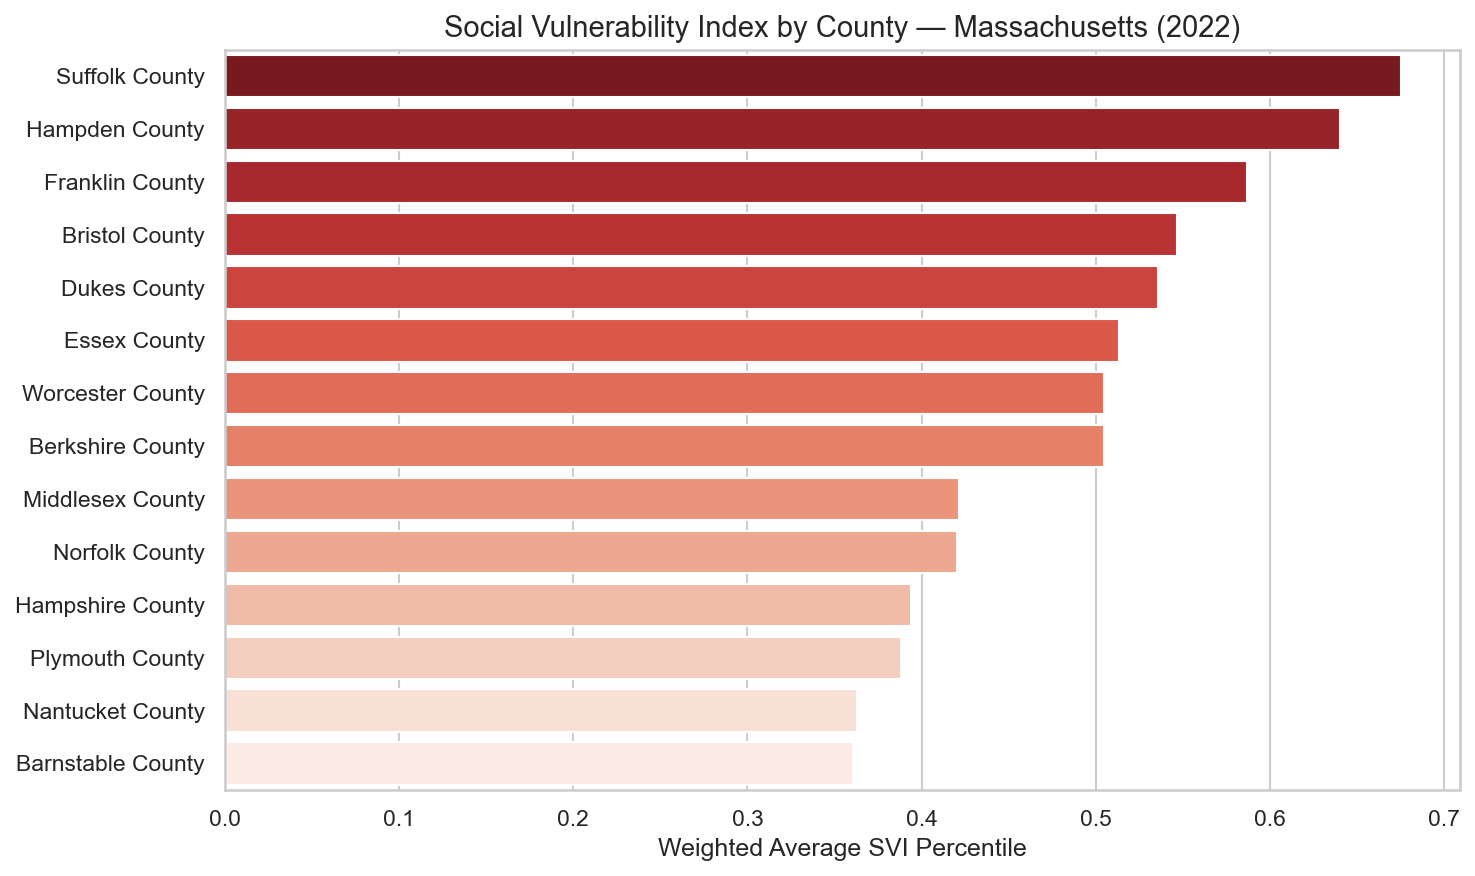

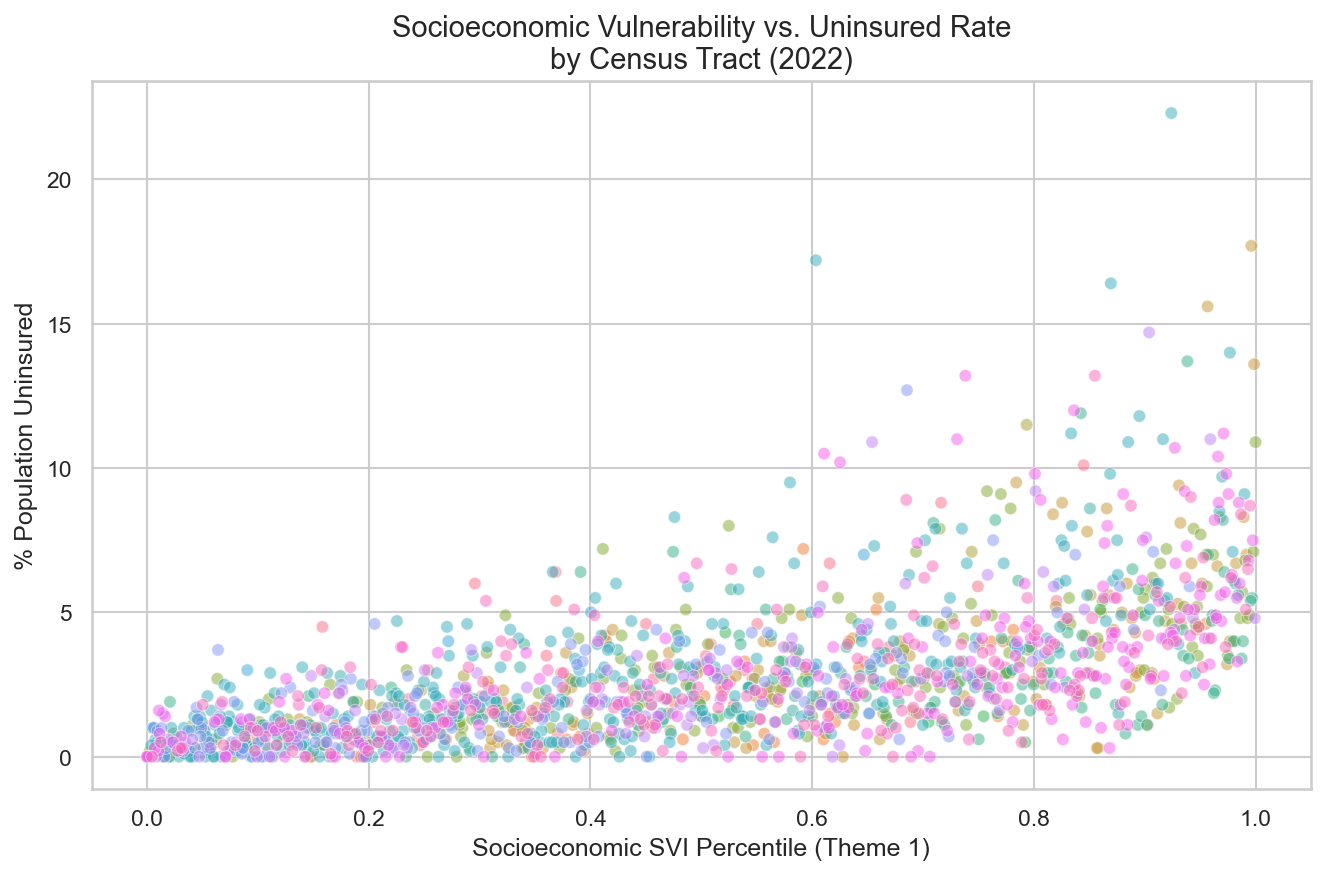

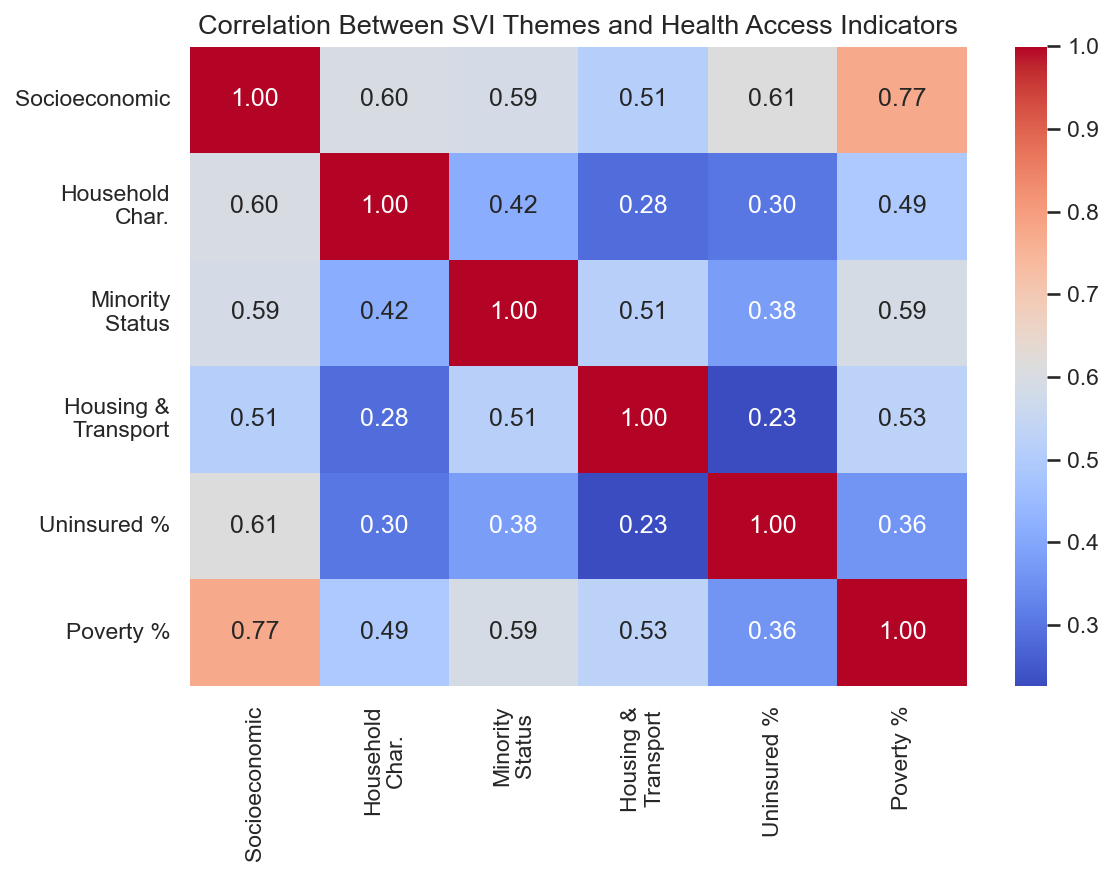

✅ All 4 figures saved to output/


In [7]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

# --- Figure 1: SVI Distribution across MA tracts ---
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_subset['RPL_THEMES'], bins=40, color='steelblue', ax=ax)
ax.set_title('Distribution of Social Vulnerability Index\nAcross Massachusetts Census Tracts (2022)', fontsize=14)
ax.set_xlabel('Overall SVI Percentile (higher = more vulnerable)')
ax.set_ylabel('Number of Tracts')
plt.tight_layout()
plt.savefig("output/fig1_svi_distribution.png")
plt.show()

# --- Figure 2: Top counties by vulnerability ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=county_summary, x='avg_overall_svi', y='COUNTY',
            hue='COUNTY', palette='Reds_r', legend=False, ax=ax)
ax.set_title('Social Vulnerability Index by County — Massachusetts (2022)', fontsize=14)
ax.set_xlabel('Weighted Average SVI Percentile')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig("output/fig2_county_svi.png")
plt.show()

# --- Figure 3: Socioeconomic vulnerability vs. uninsured rate ---
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df_subset, x='RPL_THEME1', y='EP_UNINSUR',
                hue='COUNTY', alpha=0.5, legend=False, ax=ax)
ax.set_title('Socioeconomic Vulnerability vs. Uninsured Rate\nby Census Tract (2022)', fontsize=14)
ax.set_xlabel('Socioeconomic SVI Percentile (Theme 1)')
ax.set_ylabel('% Population Uninsured')
plt.tight_layout()
plt.savefig("output/fig3_uninsured_scatter.png")
plt.show()

# --- Figure 4: Correlation heatmap ---
corr_cols = ['RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'EP_UNINSUR', 'EP_POV150']
corr_labels = ['Socioeconomic', 'Household\nChar.', 'Minority\nStatus', 
                'Housing &\nTransport', 'Uninsured %', 'Poverty %']
corr_matrix = df_subset[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=corr_labels, yticklabels=corr_labels, ax=ax)
ax.set_title('Correlation Between SVI Themes and Health Access Indicators', fontsize=13)
plt.tight_layout()
plt.savefig("output/fig4_correlation_heatmap.png")
plt.show()

print("✅ All 4 figures saved to output/")

In [8]:
# High-need tracts: top quartile of SVI AND top quartile of uninsured rate
svi_threshold = 0.75
uninsured_threshold = df_subset['EP_UNINSUR'].quantile(0.75)

high_need = df_subset[
    (df_subset['RPL_THEMES'] >= svi_threshold) &
    (df_subset['EP_UNINSUR'] >= uninsured_threshold)
].copy()

print(f"SVI threshold (top 25%): >= {svi_threshold}")
print(f"Uninsured rate threshold (top 25%): >= {uninsured_threshold:.2f}%")
print(f"\nHigh-need tracts identified: {len(high_need)}")
print(f"Total population in high-need tracts: {high_need['E_TOTPOP'].sum():,}")

print("\nHigh-need tracts by county:")
county_breakdown = high_need.groupby('COUNTY').agg(
    tract_count=('FIPS', 'count'),
    total_pop=('E_TOTPOP', 'sum'),
    avg_svi=('RPL_THEMES', 'mean'),
    avg_uninsured=('EP_UNINSUR', 'mean')
).sort_values('tract_count', ascending=False).reset_index()

print(county_breakdown.to_string())

high_need.to_csv("output/high_need_tracts.csv", index=False)
print("\n✅ High-need tracts saved to output/")

SVI threshold (top 25%): >= 0.75
Uninsured rate threshold (top 25%): >= 3.80%

High-need tracts identified: 223
Total population in high-need tracts: 955,984

High-need tracts by county:
               COUNTY  tract_count  total_pop   avg_svi avg_uninsured
0      Suffolk County           53     231703  0.909309      6.284906
1    Middlesex County           42     174984  0.851943      7.271429
2        Essex County           34     173985  0.912312      5.973529
3      Bristol County           28      93249  0.890793         7.225
4    Worcester County           22      87845  0.891318      6.118182
5      Hampden County           21      89695  0.909305       5.87619
6     Plymouth County           10      41652   0.91545          6.29
7      Norfolk County            8      44563  0.852012        5.3875
8   Barnstable County            2       7322   0.93505          8.05
9    Berkshire County            2       8269    0.8594          4.45
10    Franklin County            1       27